# Labellisez et appliquez des approches semi-supervisées en traitement d'images

** Contexte du Projet

Entreprise : CurelyticsIA (Startup E-santé)

Mission : Automatiser la détection de tumeurs cérébrales pour assister les professionnels de santé.

Données : Jeu de données d'imagerie médicale (PNG + métadonnées). La majorité des images sont non étiquetées, seul un sous-ensemble restreint dispose d'annotations expertes (Normal / Cancéreux).


** Objectifs de la Mission

Ce Notebook a pour but de réaliser une preuve de concept (PoC) visant à évaluer la faisabilité d'un passage à l'échelle. Les objectifs techniques sont les suivants :

    Exploration & Feature Extraction : Analyser la qualité des images et extraire des vecteurs de caractéristiques via un modèle pré-entraîné (ex: ResNet).
    Clustering Exploratoire : Identifier des structures naturelles dans les données non étiquetées pour générer des pseudo-labels ("labellisation faible").
    Apprentissage Semi-Supervisé : Entraîner un modèle CNN en combinant les labels experts ("forts") et les pseudo-labels ("faibles").
    Évaluation & Recommandation : Comparer les performances (Supervisé vs Semi-Supervisé) et recommander une stratégie de déploiement.
    

## Exploration du dataset



In [46]:

import pandas as pd
import os
import cv2

# Adapte the data path with your configuration
data_path = "../data"
df_images_filepath = os.path.join(data_path, "images.parquet")

# Load the dataframe with image list and basic informations
df_images = pd.read_parquet(df_images_filepath)
display(df_images)


# Création d'un dataframe de description des données, 
def describe_field(df):
    df_describ = pd.DataFrame({
        "name": df.columns,
        "dtype": df.dtypes.values,
        "unique_count": df.nunique(),
        "notna_count": df.notnull().sum().values,
    })
    # Ajout des descriptions données par la fonction describe() des champs numérique
    describe_numeric = df.describe().T.reset_index().drop(columns=['count'])
    df_describ = df_describ.merge(describe_numeric, left_on='name', right_on='index', how='left').drop(columns=['index'])
    return df_describ

df_describ = describe_field(df_images)
display(df_describ)

,path,filename,format,width,height,mode,size_bytes,is_grayscale,brightness,contrast,sharpness,bits,label
0,data/avec_labels/cancer,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,jpg,512,512,RGB,20159,True,32,37,33,8,None
1000,data/sans_label,a3337a5a-2572-42d5-b94d-737da22ff3a9.jpg,jpg,512,512,RGB,29194,True,50,34,68,8,None
1009,data/sans_label,15127f32-b7fc-4c5a-9721-c885bfedef71.jpg,jpg,512,512,RGB,23050,True,77,57,28,8,None
1008,data/sans_label,e69bc3be-ff42-4189-b00a-bc077cf2a284.jpg,jpg,512,512,RGB,16249,True,23,32,54,8,None
1007,data/sans_label,5735cc06-85b0-48a3-84c0-b636f7817ac5.jpg,jpg,512,512,RGB,23236,True,52,50,52,8,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,data/sans_label,420bc65c-4456-45ff-b5b4-19ba112649c3.jpg,jpg,512,512,RGB,28861,False,95,50,127,8,None
1303,data/sans_label,8cd4ed59-139f-4290-8455-05132107b115.jpg,jpg,512,512,RGB,29993,False,75,56,101,8,None
224,data/sans_label,974065d8-2b2e-40f2-ad74-be186b798088.jpg,jpg,512,512,RGB,26593,False,49,46,432,8,None
1055,data/sans_label,26ff3a8d-93cb-43de-aa5a-e71b74348b3b.jpg,jpg,512,512,RGB,36901,False,88,82,533,8,None


,name,dtype,unique_count,notna_count,mean,std,min,25%,50%,75%,max
0,path,str,3,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,filename,str,1506,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,format,str,1,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,width,int64,1,1506,512.000000,0.000000,512.0,512.00,512.0,512.00,512.0
4,height,int64,1,1506,512.000000,0.000000,512.0,512.00,512.0,512.00,512.0
5,mode,str,1,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,size_bytes,int64,1361,1506,24749.329349,6264.723374,13373.0,21068.25,23838.0,27306.75,75454.0
7,is_grayscale,bool,2,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,brightness,int64,97,1506,51.895750,17.379956,14.0,41.00,50.0,59.00,136.0
9,contrast,int64,72,1506,48.439575,13.717196,20.0,39.00,45.0,54.00,119.0


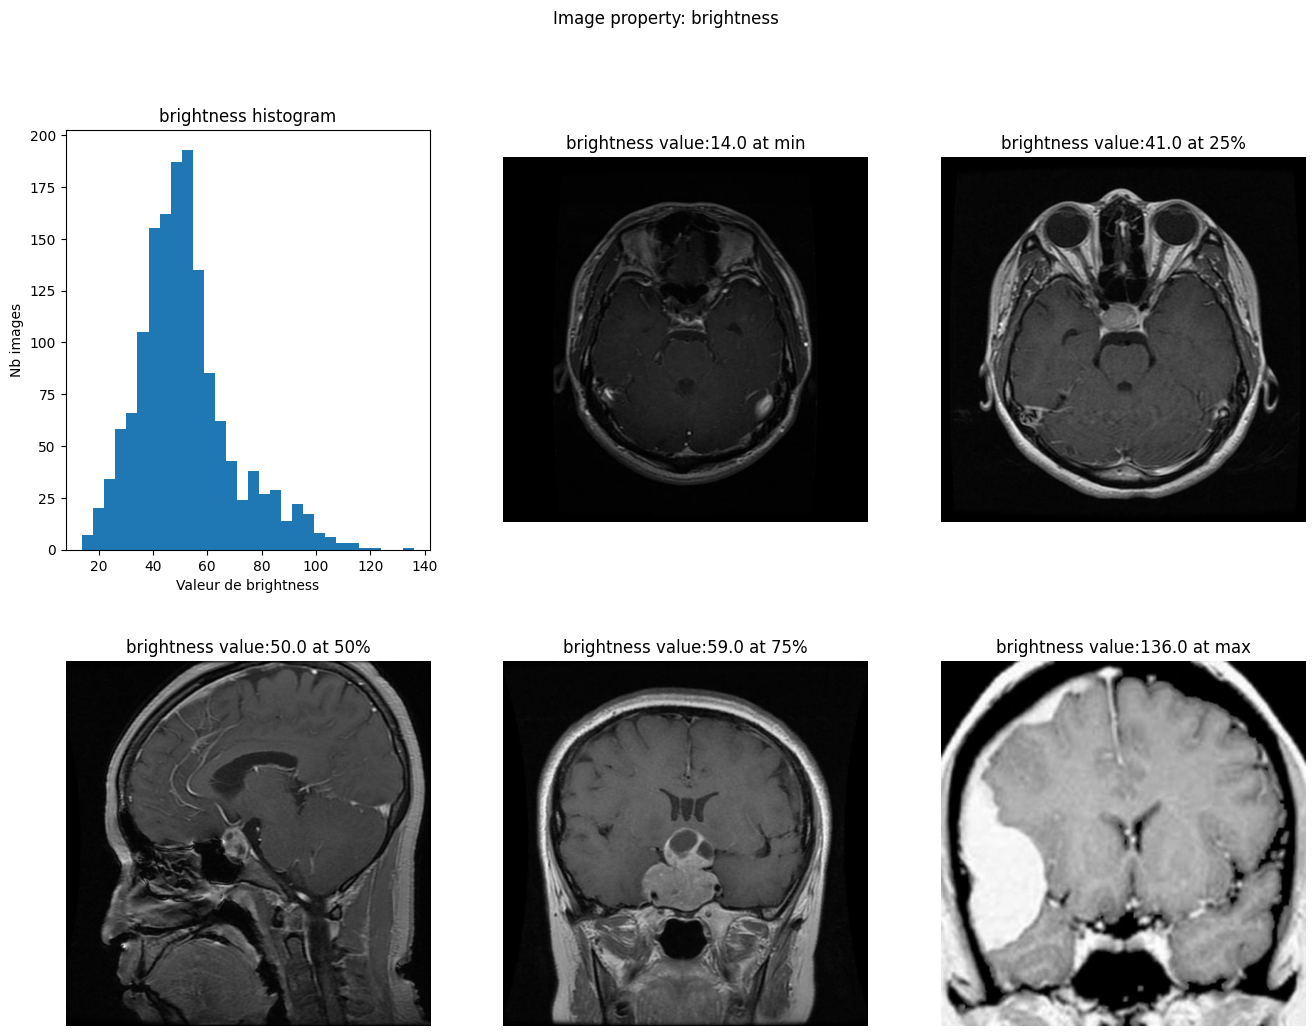

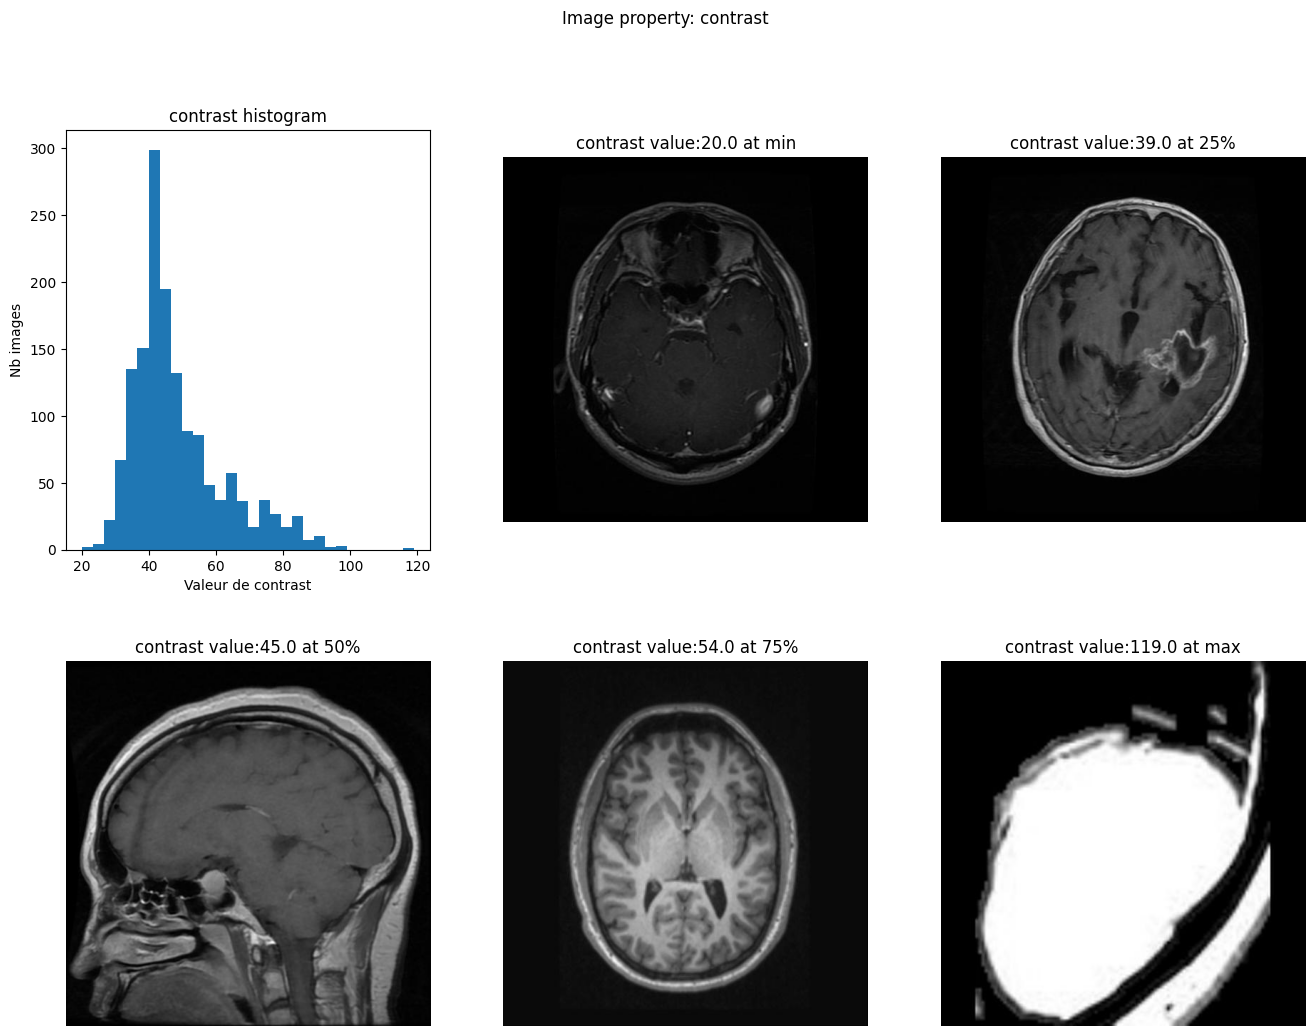

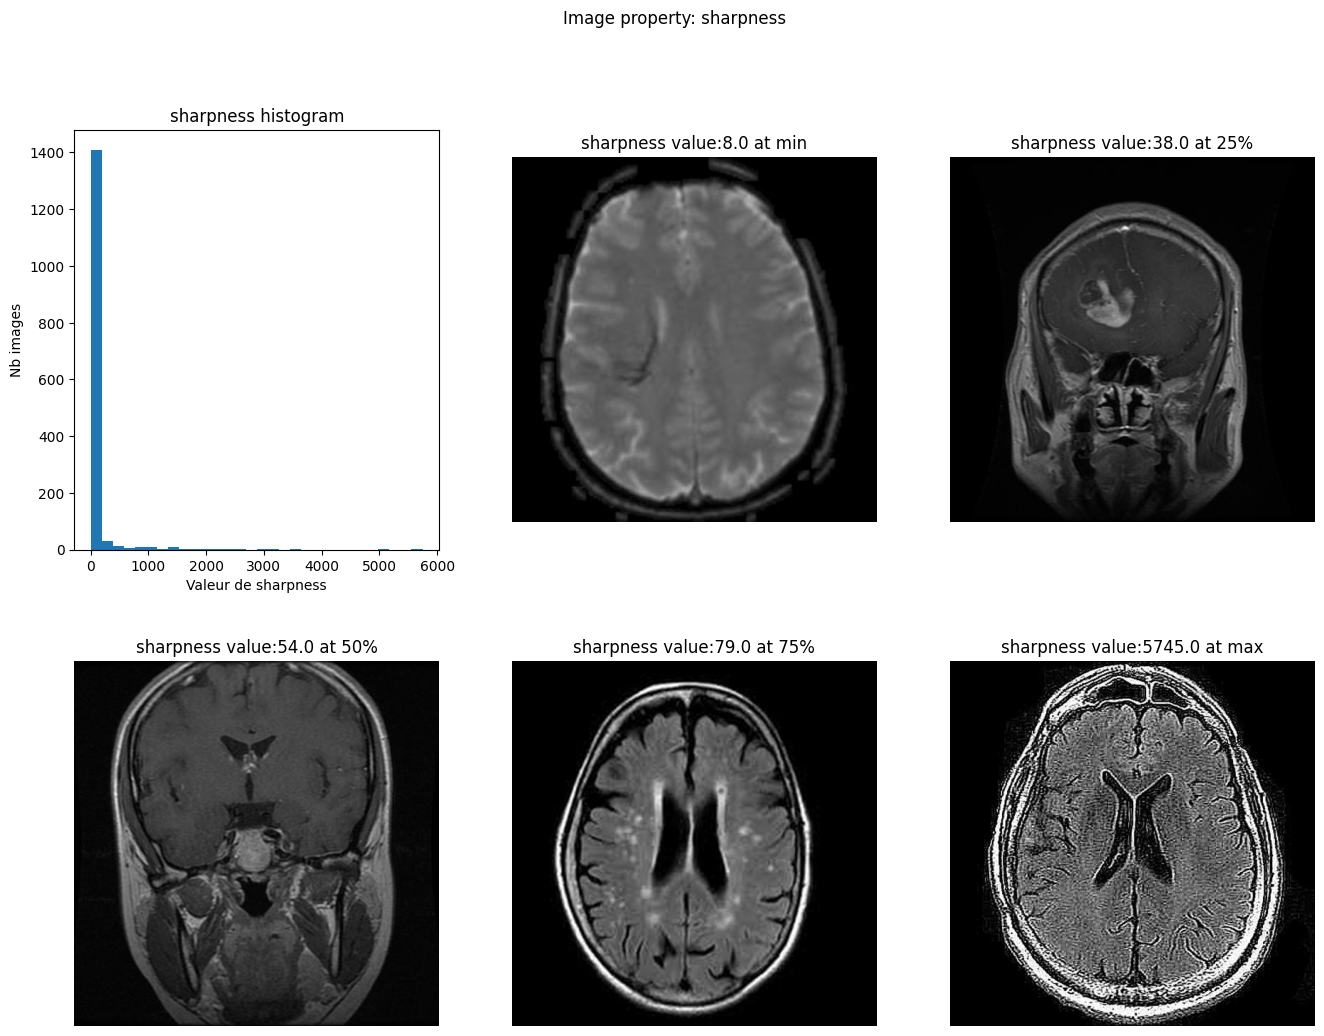

In [76]:


axs_row_max = 2
axs_col_max = 3


for img_property in ['brightness', 'contrast', 'sharpness']:

    fig, axs = plt.subplots(axs_row_max, axs_col_max, figsize=(16,12))
    fig.suptitle(f'Image property: {img_property}')
    
    axs[0, 0].hist(df_images[img_property].dropna(), bins=30)
    axs[0, 0].set_xlabel(f"Valeur de {img_property}")
    axs[0, 0].set_ylabel("Nb images")
    axs[0, 0].set_title(f"{img_property} histogram")
    
    property_row = df_describ.loc[(df_describ['name'] == img_property)].iloc[0]

    axs_row = 0
    axs_col = 1
    
    for seuil in ['min', '25%', '50%', '75%', 'max']:
        
        img_row = df_images.loc[(df_images[img_property] == property_row[seuil])]
        
        if len(img_row) >= 1:
            
            file_path = os.path.join("../", img_row.iloc[0]["path"], img_row.iloc[0]["filename"])
            img = cv2.imread(file_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axs[axs_row, axs_col].imshow(img)
            axs[axs_row, axs_col].set_title(f'{img_property} value:{property_row[seuil]} at {seuil}')
            axs[axs_row, axs_col].axis("off")

            axs_col += 1
            if axs_col == axs_col_max:
                axs_col = 0
                axs_row += 1
                

            
    plt.show()
            

    